In [4]:
import os
import csv
import cv2
import numpy as np

# Image dimensions
ORIGINAL_WIDTH = 3024
ORIGINAL_HEIGHT = 4032
CROP_Y_START = 0
CROP_Y_END = 900

# --- Fixed Green HSV Range (Includes Dark Green) ---
FIXED_GREEN_LOWER = np.array([30, 40, 20])  # Captures darker greens
FIXED_GREEN_UPPER = np.array([90, 255, 255])  # Covers bright greens as well

def count_valid_pixels(mask, min_size):
    """Cleans the mask and filters contours by size"""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(mask_clean)

    for cnt in contours:
        if cv2.contourArea(cnt) >= min_size:
            temp_mask = np.zeros_like(mask_clean)
            cv2.drawContours(temp_mask, [cnt], 0, 255, -1)
            filtered_mask = cv2.bitwise_or(filtered_mask, cv2.bitwise_and(temp_mask, mask_clean))
    
    return cv2.countNonZero(filtered_mask), filtered_mask

def generate_single_mask(input_path, output_folder, green_params, custom_params=None,custom_params2=None, target_pixel_count=0,output_csv_file="pixel_count_result.csv", min_contour=100, crop=False):
    """
    Generates segmentation masks, compares raw and filtered masks against target pixel counts,
    and calculates percentage differences.

    If `crop=True`, removes the top 900 pixels before processing. The final mask is restored
    to 3024x4032 by adding black to the cropped-out region.

    Parameters:
      - input_path: Path to the input image.
      - output_folder: Folder where mask images will be saved.
      - target_pixel_count: Expected pixel count for evaluation.
      - output_csv_file: CSV file for storing results.
      - custom_params: Dictionary with custom HSV threshold parameters.
      - min_contour: Minimum contour size to keep.
      - crop: If True, removes the top 900 pixels before processing and restores black padding.
    """

    # Set up cache folder for cropped images
    cropped_folder = os.path.join(output_folder, "cropped_cache")
    os.makedirs(cropped_folder, exist_ok=True)
   
    lower_green = np.array([green_params["green_hue_min"], green_params["green_sat_min"], green_params["green_val_min"]])
    upper_green = np.array([green_params["green_hue_max"], green_params["green_sat_max"], green_params["green_val_max"]])
   
    if custom_params is not None: 
        lower_custom = np.array([custom_params["custom_hue_min"], custom_params["custom_sat_min"], custom_params["custom_val_min"]])
        upper_custom = np.array([custom_params["custom_hue_max"], custom_params["custom_sat_max"], custom_params["custom_val_max"]])
    
    if custom_params2 is not None:
        lower_custom2 = np.array([custom_params2["custom2_hue_min"], custom_params2["custom2_sat_min"], custom_params2["custom2_val_min"]])
        upper_custom2 = np.array([custom_params2["custom2_hue_max"], custom_params2["custom2_sat_max"], custom_params2["custom2_val_max"]])
    
    # Ensure output folder exists
    os.makedirs(output_folder, exist_ok=True)

    filename = os.path.basename(input_path)
    file_base = os.path.splitext(filename)[0]  # Remove file extension

    img_path = input_path
    cropped_path = os.path.join(cropped_folder, filename)  # Cached cropped image

    # Load image, checking if cropped version exists
    if crop and os.path.exists(cropped_path):
        img = cv2.imread(cropped_path)  # ✅ Load cached cropped image
    else:
        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ Could not read image: {filename}")
            return
        
        if crop:
            img = img[CROP_Y_END:, :]  # Crop only once
            cv2.imwrite(cropped_path, img)  # ✅ Save cropped image for future runs

    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Apply fixed green mask
    mask_green = cv2.inRange(hsv, lower_green, upper_green)

    if (custom_params is None) or (custom_params2 is None):
        combined_mask = mask_green
    else:        
        # Apply best-found yellow and tan mask
        mask_custom = cv2.inRange(hsv, lower_custom, upper_custom)    
        mask_custom2 = cv2.inRange(hsv,lower_custom2,upper_custom2)

        # Combine all masks
        mask_1 = cv2.bitwise_or(mask_green, mask_custom)
        combined_mask = cv2.bitwise_or(mask_custom2,mask_1)
    
    # Get raw pixel count before filtering
    raw_pixel_count = cv2.countNonZero(combined_mask)

    # Apply contour filtering
    filtered_pixel_count, cropped_final_mask = count_valid_pixels(combined_mask, min_contour)

    # Restore mask to original size if cropped
    if crop:
        final_mask = np.zeros((ORIGINAL_HEIGHT, ORIGINAL_WIDTH), dtype=np.uint8)  # Create blank mask
        final_mask[CROP_Y_END:, :] = cropped_final_mask  # Insert cropped mask in lower portion
        final_raw_mask = np.zeros((ORIGINAL_HEIGHT, ORIGINAL_WIDTH), dtype=np.uint8)
        final_raw_mask[CROP_Y_END:, :] = combined_mask
    else:
        final_mask = cropped_final_mask  # No cropping, use original
        final_raw_mask = combined_mask

    # Calculate percentage differences
    if target_pixel_count == 0:
        raw_difference = 100.0 if raw_pixel_count > 0 else 0.0
        filtered_difference = 100.0 if filtered_pixel_count > 0 else 0.0
    else:
        raw_difference = abs(raw_pixel_count - target_pixel_count) / target_pixel_count * 100
        filtered_difference = abs(filtered_pixel_count - target_pixel_count) / target_pixel_count * 100

    print(f"🔹 Raw Mask Difference: {raw_difference:.2f}%")
    print(f"🔹 Filtered Mask Difference: {filtered_difference:.2f}%")
    print(f"✅ Filtered Mask Count: {filtered_pixel_count}")
    print(f"✅ Target Mask Count: {target_pixel_count}")
    # Save raw and final masks
    # cv2.imwrite(os.path.join(output_folder, f"{file_base}_raw.jpg"), final_raw_mask)
    cv2.imwrite(os.path.join(output_folder, f"{file_base}_mask.jpg"), final_mask)

    # **APPEND Results to CSV Instead of Overwriting**
    csv_exists = os.path.exists(output_csv_file)
    
    with open(output_csv_file, "a", newline='') as csvfile:
        writer = csv.writer(csvfile)
        
        # Write header only if the file is newly created
        if not csv_exists:
            writer.writerow(["filename", "raw_pixel_count", "filtered_pixel_count", "target_pixel_count", "raw_difference", "filtered_difference"])
        
        # Append new results
        writer.writerow([file_base, raw_pixel_count, filtered_pixel_count, target_pixel_count, raw_difference, filtered_difference])

    print(f"✅ Masks saved in: {output_folder}")
    print(f"✅ Results appended to: {output_csv_file}")


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

def visualize_mask(image_path, mask_path, alpha=0.7, output_dir=""):
    """
    Visually examines the predicted mask:
    1. Overlays the mask on the original image.
    2. Crops out the masked region.
    3. Removes the mask area but keeps the original background.

    Args:
    - image_path (str): Path to the original image.
    - mask_path (str): Path to the predicted mask (binary mask).
    - alpha (float): Transparency of the overlay.
    - output_dir (str): Base directory to save visualizations.
    """

    # **Extract filename without extension**
    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # **Create output directory for this image**
    image_output_dir = os.path.join(output_dir, base_name)
    os.makedirs(image_output_dir, exist_ok=True)

    # **Define save paths**
    overlay_path = os.path.join(image_output_dir, "overlay.png")
    cropped_path = os.path.join(image_output_dir, "cropped.png")
    removed_path = os.path.join(image_output_dir, "mask_removed.png")

    # **Load and preprocess image**
    img = Image.open(image_path).convert("RGB")
    img = ImageOps.exif_transpose(img)  # Fix EXIF rotation
    img = np.array(img)

    # **Load and preprocess mask**
    mask = np.array(Image.open(mask_path).convert("L"))  # Convert to grayscale
    mask = mask / 255.0  # Normalize mask to [0,1]

    # **Ensure mask matches image size**
    if mask.shape[:2] != img.shape[:2]:
        print("⚠️ Warning: Image and mask dimensions do not match! Resizing mask...")
        mask = np.array(Image.fromarray((mask * 255).astype(np.uint8)).resize(img.shape[1::-1], Image.BILINEAR)) / 255.0

    # **1️⃣ Create Overlay**
    overlay = img.copy()
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + mask * 255 * alpha, 0, 255)  # Red tint for mask

    # **2️⃣ Crop the masked region**
    masked_region = img.copy()
    masked_region[mask < 0.5] = [0, 0, 0]  # Remove background (black out non-mask areas)

    # **3️⃣ Remove mask from original image (keep background)**
    mask_removed = img.copy()
    mask_removed[mask > 0.5] = [255, 255, 255]  # Replace masked areas with white

    # **Save images in the created folder**
    Image.fromarray(overlay.astype(np.uint8)).save(overlay_path)
    Image.fromarray(masked_region.astype(np.uint8)).save(cropped_path)
    Image.fromarray(mask_removed.astype(np.uint8)).save(removed_path)

    # **4️⃣ Display results**
    for img_data, title, save_path in zip(
        [overlay, masked_region, mask_removed],
        ["🔹 Overlay: Mask on Image", "🔹 Cropped: Only Masked Region", "🔹 Mask Removed: Original Image Kept"],
        [overlay_path, cropped_path, removed_path]
    ):
        plt.figure(figsize=(16, 14))
        plt.imshow(img_data)
        plt.title(title)
        plt.axis("off")
        plt.show()

    print(f"✅ Images saved in: {image_output_dir}")
    print(f"   - Overlay: {overlay_path}")
    print(f"   - Cropped: {cropped_path}")
    print(f"   - Mask Removed: {removed_path}")


🔹 Raw Mask Difference: 100.00%
🔹 Filtered Mask Difference: 100.00%
✅ Filtered Mask Count: 1223209
✅ Target Mask Count: 0
✅ Masks saved in: masks
✅ Results appended to: pixel_count_result.csv
Execution Time: 0.242811 seconds


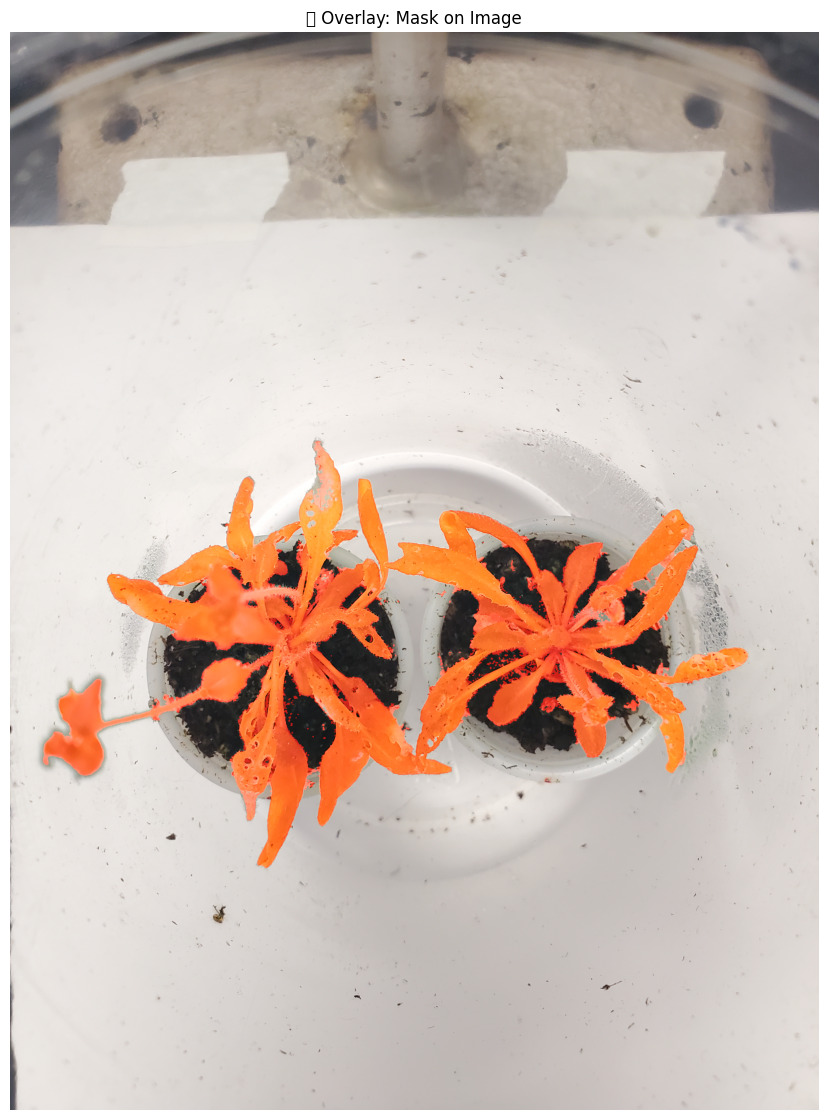

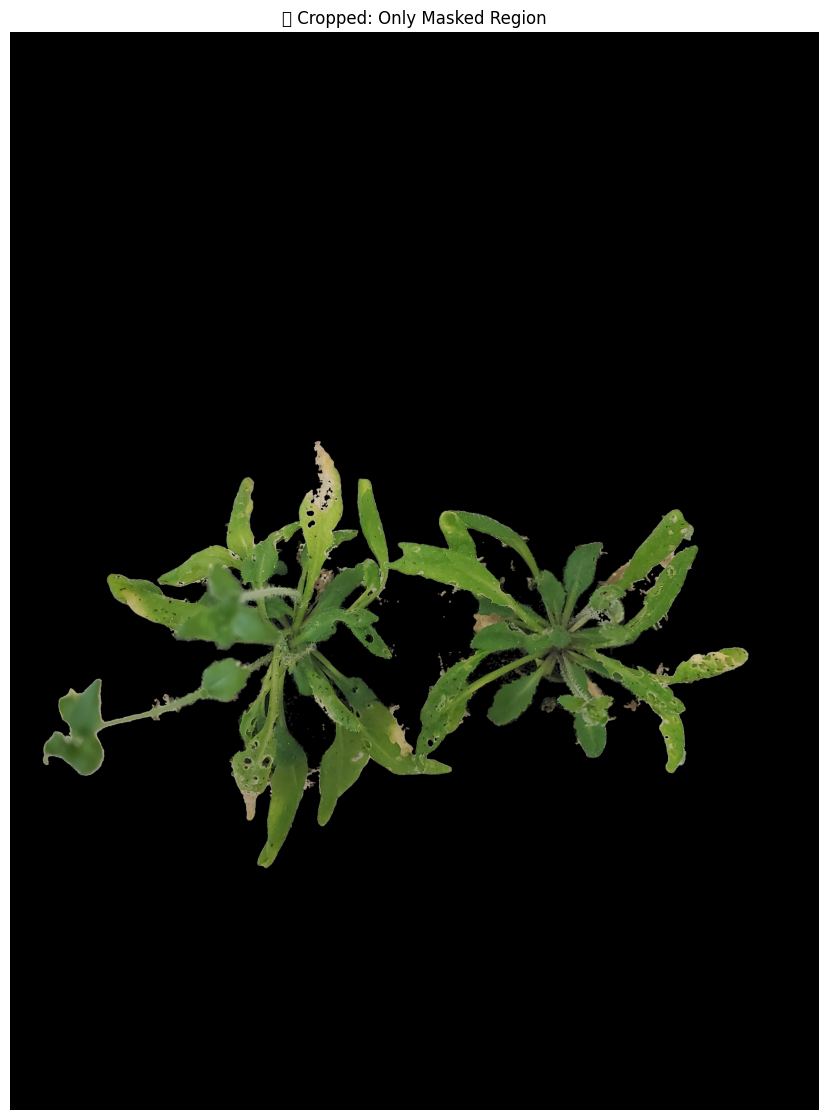

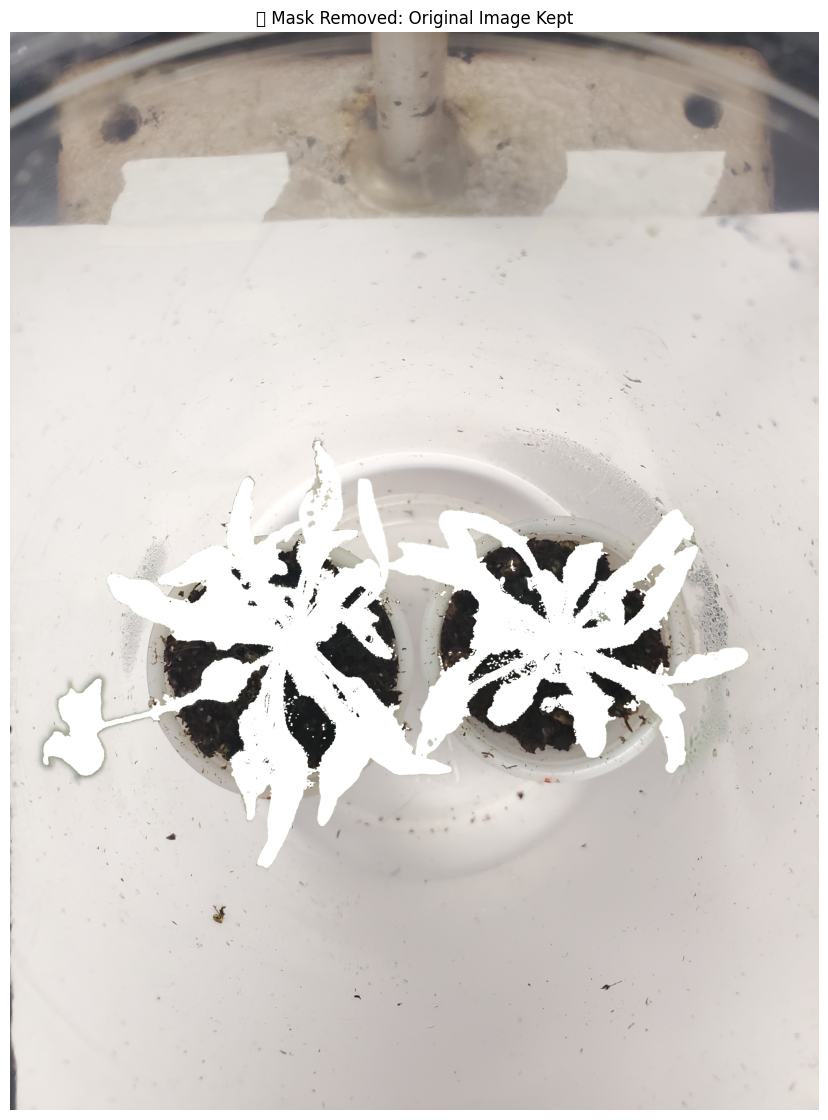

✅ Images saved in: visuals/20240727_112657
   - Overlay: visuals/20240727_112657/overlay.png
   - Cropped: visuals/20240727_112657/cropped.png
   - Mask Removed: visuals/20240727_112657/mask_removed.png


In [ ]:
import time
file_base = "20240727_112657"
input_filename = f"{file_base}.jpg"
output_folder = "masks"

min_contour = 5000
crop = True


green_params = {
        "green_hue_min": 25,
        "green_sat_min": 34,
        "green_val_min": 20,
    
        "green_hue_max": 90,
        "green_sat_max": 255,
        "green_val_max": 255
    }

custom_params = {
        "custom_hue_min": 16,
        "custom_sat_min": 45,
        "custom_val_min": 62,
    
        "custom_hue_max": 24,
        "custom_sat_max": 255,
        "custom_val_max": 255
    }

custom_params2 = {
        "custom2_hue_min": 9,
        "custom2_sat_min": 40,
        "custom2_val_min": 85,
    
        "custom2_hue_max": 14,
        "custom2_sat_max": 165,
        "custom2_val_max": 210
    }


start_time = time.perf_counter()
# custom_params = None
generate_single_mask(
    input_path=input_filename, 
    output_folder=output_folder, 
    green_params=green_params,    
    custom_params=custom_params,
    custom_params2=custom_params2,
    min_contour=min_contour, 
    crop=crop
)
# End time
end_time = time.perf_counter()

# Compute Execution Time
execution_time = end_time - start_time
print(f"Execution Time: {execution_time:.6f} seconds")
mask_path = f"masks/{file_base}_mask.jpg"

print("🔍 Visualizing mask...")
visualize_mask(input_filename, mask_path, output_dir="visuals")